# Heirarchal Clustering Model

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering


In [130]:
data = pd.read_csv('/Users/sa12/Documents/Repositories/MusicReccomendation/MusicRecommendation/Data/clean_data.csv')
data2= pd.read_csv('/Users/sa12/Documents/Repositories/MusicReccomendation/MusicRecommendation/Data/train.csv')
test_data = pd.read_csv('/Users/sa12/Documents/Repositories/MusicReccomendation/MusicRecommendation/Data/test_data.csv')
#unfortunately our genre encoding too heavily effects the data and must be removed along with our Unnamed:0 column
data = data.drop(columns=['Unnamed: 0','genre_blues', 'genre_country','genre_hip hop', 'genre_jazz', 'genre_pop', 'genre_reggae','genre_rock'])
data.columns

Index(['dating', 'violence', 'world/life', 'night/time', 'shake the audience',
       'family/gospel', 'romantic', 'communication', 'obscene', 'music',
       'movement/places', 'light/visual perceptions', 'family/spiritual',
       'sadness', 'feelings', 'age'],
      dtype='object')

In [109]:
#create X1 using the values from columns we have chosen
X1 = data.loc[:, ['dating', 'violence', 'world/life', 'night/time', 'shake the audience',
       'family/gospel', 'romantic', 'communication', 'obscene', 'music',
       'movement/places', 'light/visual perceptions', 'family/spiritual',
       'sadness', 'feelings', 'age']].values

### Average Linkage Dendrogram

groups based on the average euclidean distance of all samples in a cluster. It seeks to group based on the smallest combined distances.

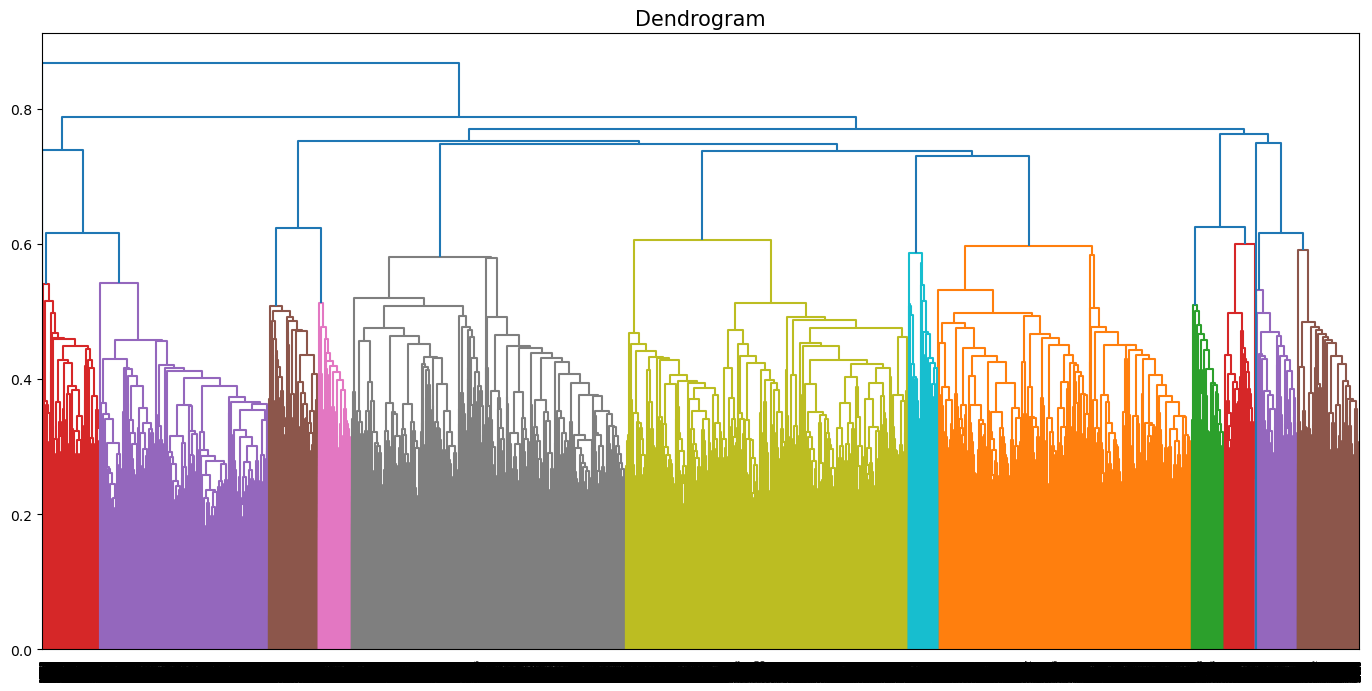

In [110]:
plt.figure(figsize = (17, 8))

# TODO: create dendogram using the "average" linkage method
# DOCUMENTATION: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html
dendo = dendrogram(linkage(X1, method = 'average'))
plt.title('Dendrogram', fontsize = 15)
plt.xticks()
plt.show()

### Centroid Linkage Dendrogram

Creates clusters based the distance between cluster centroids.

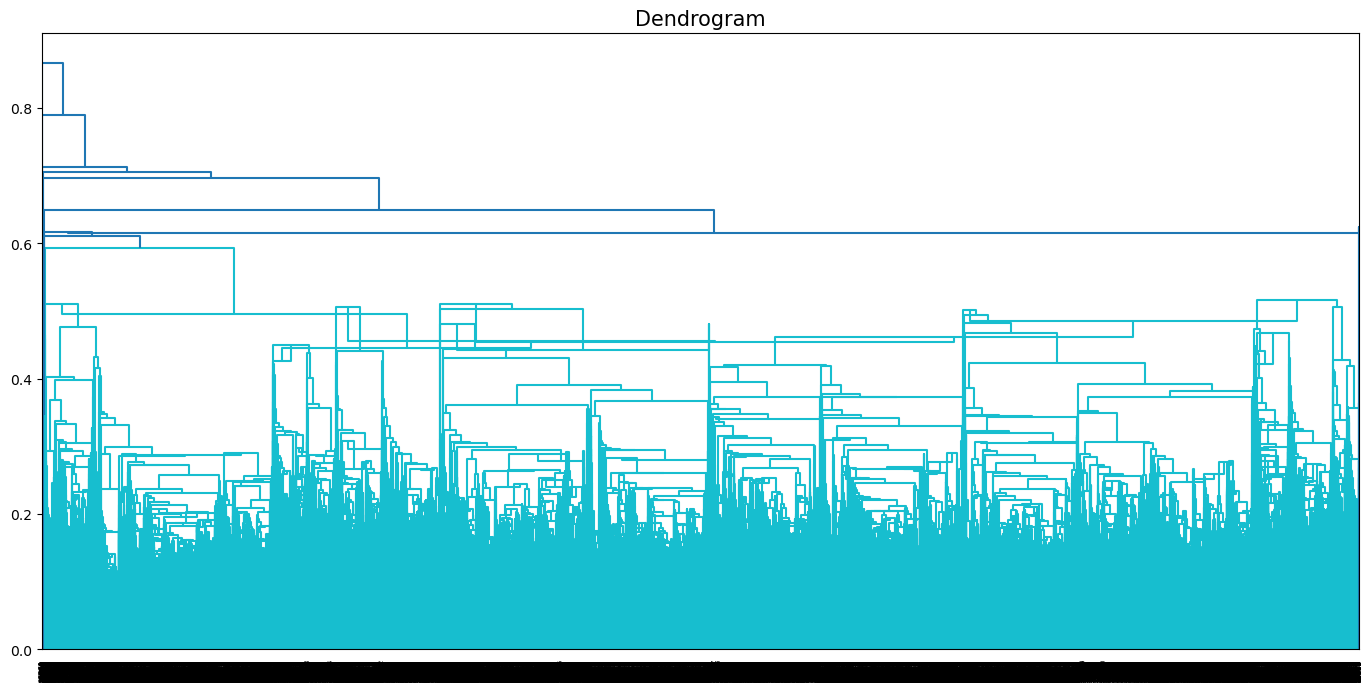

In [111]:
plt.figure(figsize = (17, 8))
dendo3 = dendrogram(linkage(X1, method = 'centroid'))
plt.title('Dendrogram', fontsize = 15)
plt.show()

### Ward Linkage Dendrogram

Combines clusters based on average sum of squares distance between them. It seeks to minimize variance when combining clusters.

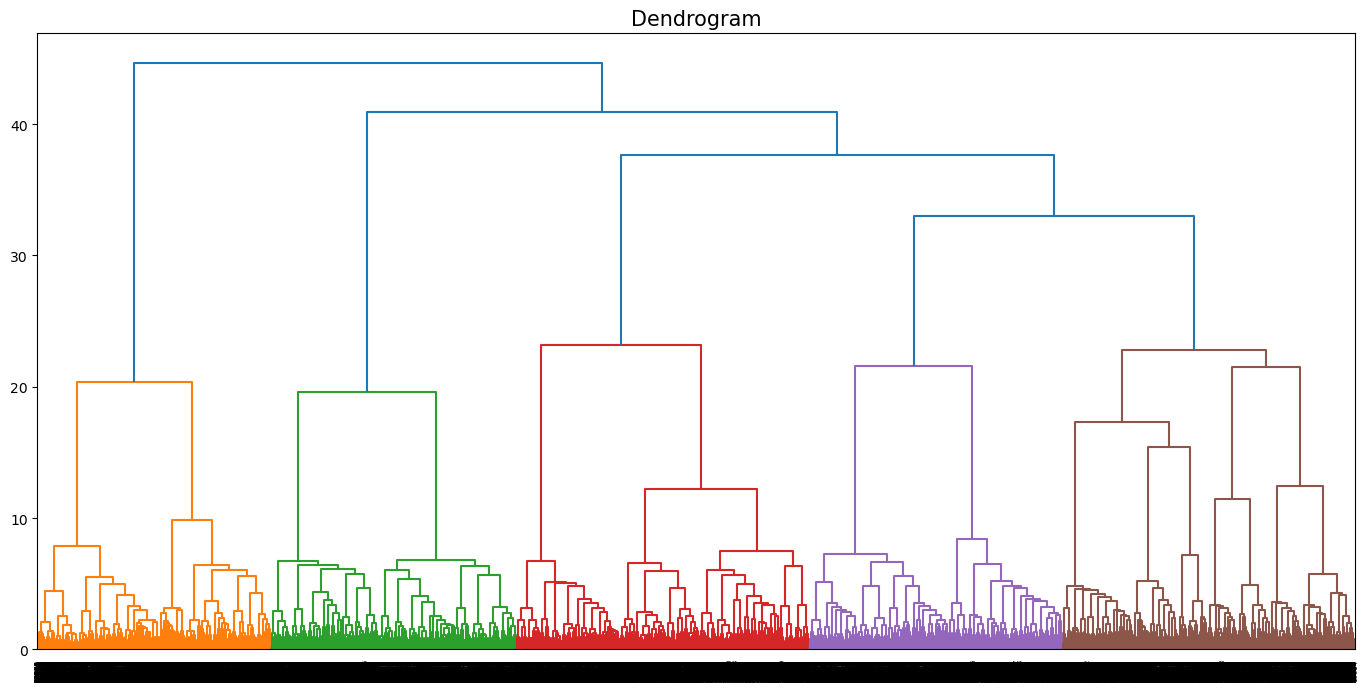

In [112]:
plt.figure(figsize = (17, 8))
dendo = dendrogram(linkage(X1, method = 'ward'))
plt.title('Dendrogram', fontsize = 15)
plt.show()

##### Out of all the models, the ward model seems to be the cleanest clustering of the data. While the graphic indicates 5 cluster is most optimal, I believe 10 is the optimal cut for our purposes.

In [113]:
agc = AgglomerativeClustering(n_clusters = 10, metric = 'euclidean', linkage = 'ward')
# fit and predict labels using `X1` dataset
ward_labels = agc.fit_predict(X1)
data['labels'] = ward_labels
#create labels for our full dataset 
data2['labels'] = ward_labels
data['labels'].value_counts()


labels
0    5282
4    4067
2    3135
7    2983
9    2642
8    2473
6    2397
5    2241
1    1801
3    1341
Name: count, dtype: int64

Similar amounts in all clusters bodes very well for this model.

In [114]:
#isolate each cluster for evaluation
cluster1 = data[data['labels'] == 0]
cluster2 = data[data['labels'] == 1]
cluster3 = data[data['labels'] == 2]
cluster4 = data[data['labels'] == 3]
cluster5 = data[data['labels'] == 4]
cluster6 = data[data['labels'] == 5]
cluster7 = data[data['labels'] == 6]
cluster8 = data[data['labels'] == 7]
cluster9 = data[data['labels'] == 8]
cluster10 = data[data['labels'] == 9]

Now that we've seperated them all out, lets see how each column deviates from the mean for each cluster.

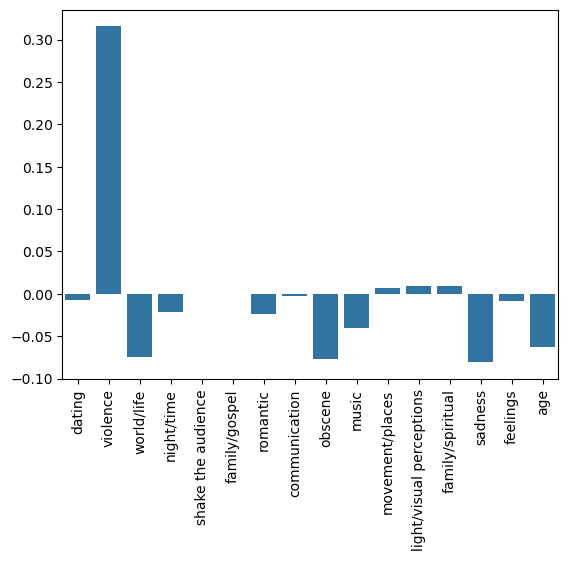

In [115]:
#save the label data and than drop labels in data because we already seperated by labels
label_data = data['labels']
label_data.to_csv('/Users/sa12/Documents/Repositories/MusicReccomendation/MusicRecommendation/Data/HC_labels.csv')
data = data.drop(columns='labels')
#same for cluster1
cluster1 = cluster1.drop(columns='labels')
#distance from mean
c1 = cluster1.mean() - data.mean()
sns.barplot(c1)
plt.xticks(rotation=90)
plt.show()

## Cluster 1 is songs that are high in violence. 

#### Notably, these songs are not obsene or sad, and tend to be newer.

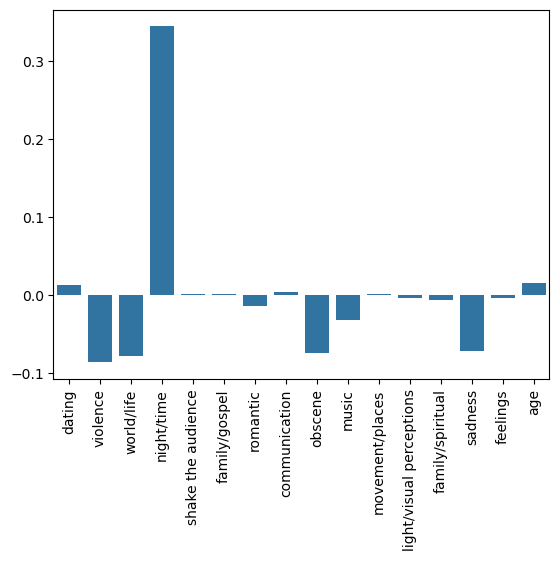

In [116]:
cluster2 = cluster2.drop(columns='labels')
c2 = cluster2.mean() - data.mean()
sns.barplot(c2)
plt.xticks(rotation=90)
plt.show()

## Cluster 2 is songs that are about night/time.   

#### These songs are not obsene or sad, but they are very non violent. Looking at our dendrogram, that is the key feature that splits these two clusters.

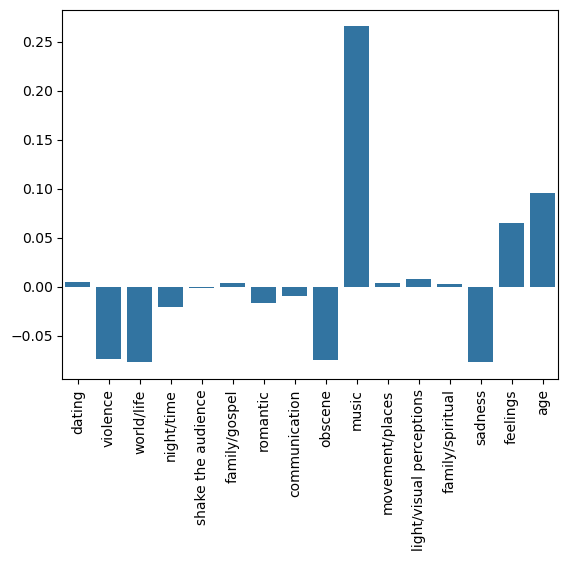

In [117]:
cluster3 = cluster3.drop(columns='labels')
c3 = cluster3.mean() - data.mean()
sns.barplot(c3)
plt.xticks(rotation=90)
plt.show()

## Cluster 3 is songs about music. 

#### These songs tend to be older and have content about feelings other than sadness. 

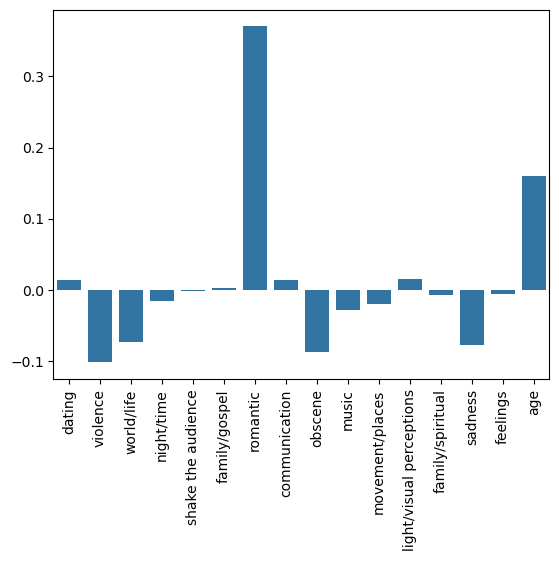

In [118]:
cluster4 = cluster4.drop(columns='labels')
c4 = cluster4.mean() - data.mean()
sns.barplot(c4)
plt.xticks(rotation=90)
plt.show()

## Cluster 4 is songs about romance. 

#### These songs are much older on average, but do not appear to sad songs either.

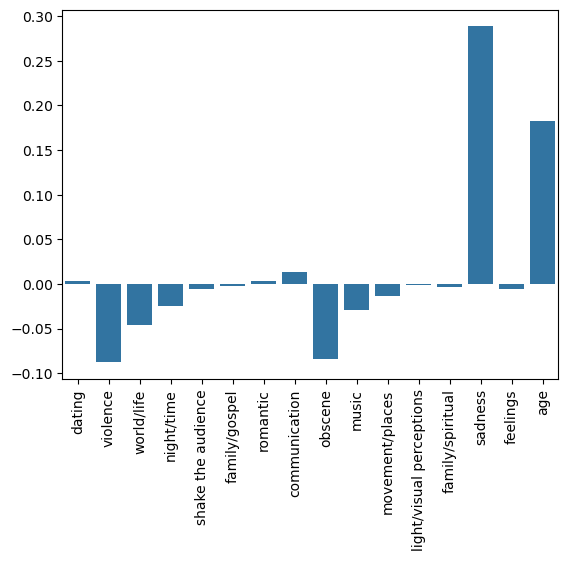

In [119]:
cluster5 = cluster5.drop(columns='labels')
c5 = cluster5.mean() - data.mean()
sns.barplot(c5)
plt.xticks(rotation=90)
plt.show()

## Cluster 5 are the sad, sad songs. 

#### These songs are much older on average, as well.

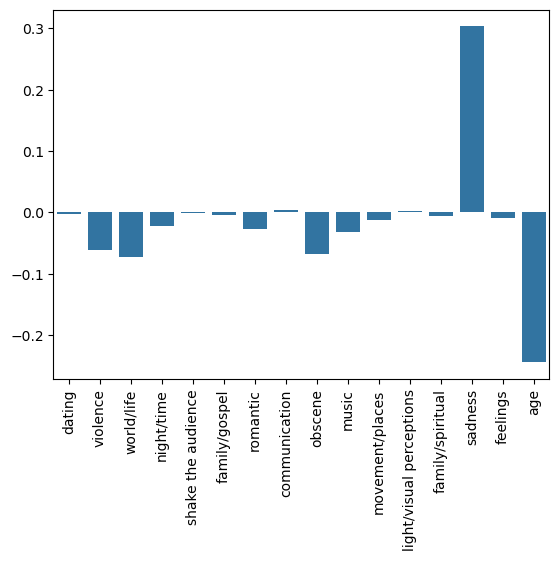

In [120]:
cluster6 = cluster6.drop(columns='labels')
c6 = cluster6.mean() - data.mean()
sns.barplot(c6)
plt.xticks(rotation=90)
plt.show()

## Cluster 6 are sad songs, too, but these songs are much younger on average.

#### I find this split very interesting, because much of the other data remained the same. It seems that there is a large enough difference between old and new sad songs to classify them sepereately.

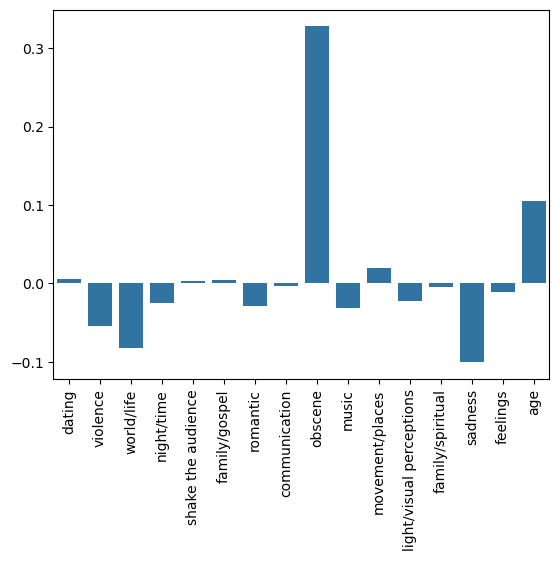

In [121]:
cluster7 = cluster7.drop(columns='labels')
c7 = cluster7.mean() - data.mean()
sns.barplot(c7)
plt.xticks(rotation=90)
plt.show()

## Cluster 7 is songs with high obsenity. 

#### These songs are older, given the  younger relative age of hip-hop this could very well be obsene songs not hip-hop

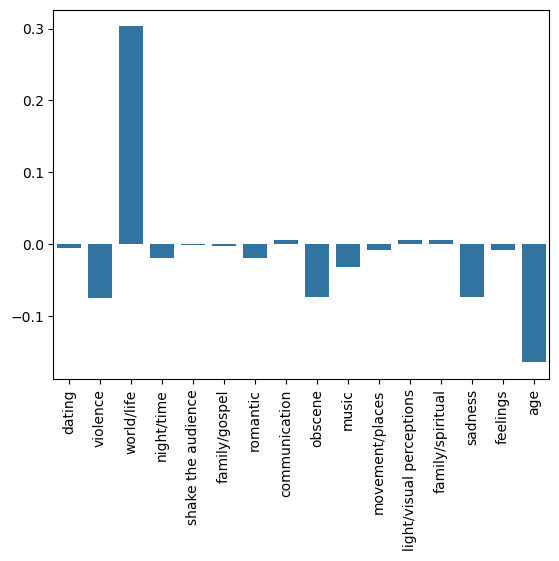

In [122]:
cluster8 = cluster8.drop(columns='labels')
c8 = cluster8.mean() - data.mean()
sns.barplot(c8)
plt.xticks(rotation=90)
plt.show()

## Cluster 8 is songs that reference the world/life. 

#### These songs tend to be younger, probably because the internet has made these topics much more contemperary.

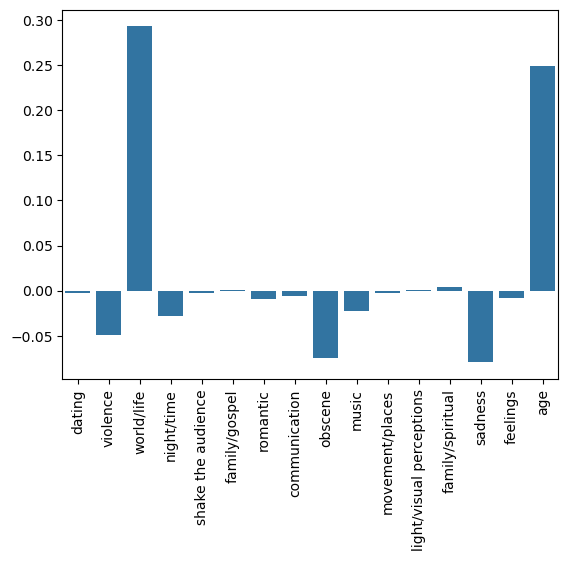

In [123]:
cluster9 = cluster9.drop(columns='labels')
c9 = cluster9.mean() - data.mean()
sns.barplot(c9)
plt.xticks(rotation=90)
plt.show()

## Cluster 9 is songs about world/life that skew far older. 

#### This is the second split based on age. 

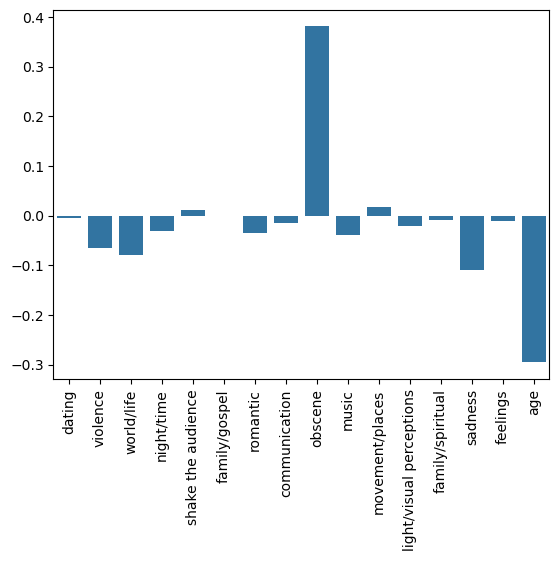

In [124]:
cluster10 = cluster10.drop(columns='labels')
c10 = cluster10.mean() - data.mean()
sns.barplot(c10)
plt.xticks(rotation=90)
plt.show()

## Cluster 10 is obsene songs that are much younger 

#### The young age and high obsenity means this is where hip-hop is likely clustered.

# Model Evaluation

Our heirarchal clustering algorithm did a good job creating 10 approximetely even clusters. 

Cluster 1 & 2 were both notably low in sadness, obsenity and world/life in roughly equal measures. Theese are seperate clusters because Cluster 1 scored very highly in violence, while Cluster 2 scored highly in night/time. In real world terms, 

Clusters 3 & 4 also notably scored low in sadness(but high in feeling), obsenity and low in both violence and world/life. Cluster 3 has a notable feature of being strongly about music, while Cluster 4 is heavily skewed towards romantic content. This content heavily leans older, but our EDA showed romantic content is naturally older.

Clusters 5 & 6 are all of our sad songs. The clusters are seperated based on their age, with cluster 5 being older sad songs and cluster 6 being newer sad songs. The rest of the data follows age based trend we saw. This clustering is strange, as we saw no clear age seperation in our sadness catagory in our EDA. 

Cluster 7 is songs high in obsentiy that are older. Remember that our EDA showed most obsenity was in hip-hop & reggae, but these genres skewed older. This must be the cluster of older obsene songs. Kenny Rodgers - Gambler type stuff maybe?

Clusters 8 & 9 are nearly identical, but the ages are flipped. This is where our most representative world/life values fell. These values were then clustered based on tehir defining factor, age. Cluster 8 is newer songs about life. Cluster 9 is older songs about life. Knowing how much stuff has changed, this clustering makes a lot of sense.

Cluster 10 is younger, obsene songs.  This is the home of hip-hop and reggae.

##### Applying to test data

In [142]:
full_data = pd.concat((data2,test_data), join='inner')
X2 = full_data.loc[:, ['dating', 'violence', 'world/life', 'night/time', 'shake the audience',
       'family/gospel', 'romantic', 'communication', 'obscene', 'music',
       'movement/places', 'light/visual perceptions', 'family/spiritual',
       'sadness', 'feelings', 'age']].values
full_labels = agc.fit_predict(X2)
full_data['labels'] = full_labels

In [152]:
test_songs = (full_data[full_data['track_name'].isin(test_data['track_name'])])
test_songs = test_songs.drop(index=[17136,26715])
test_data.to_csv('/Users/sa12/Documents/Repositories/MusicReccomendation/MusicRecommendation/Data/tested_hc_data')

In [156]:
test_songs = test_songs[['artist_name', 'track_name','genre','labels']]
#add one to label column cause I misnamed my cluster.
test_songs['labels'] = test_songs['labels'] + 1
test_songs

,artist_name,track_name,genre,labels
0,godsmack,immune,rock,9
1,dennis brown,second chance,reggae,2
2,the black crowes,sister luck,pop,1
3,jerry lee lewis,your cheating heart,pop,5
4,paul anka,eso beso,pop,4
5,noro morales,silencio,jazz,1
6,rage against the machine,pistol grip pump,rock,7
7,taste,railway and gun,blues,5
8,randy travis,messin' with my mind,country,2
9,paramore,playing god,pop,1
